# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Nazwar Fakhrurrozy | 5054251040 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
df = pd.read_csv('bankruptcy.csv')
df.columns = df.columns.str.strip()
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print("\n" + "="*50 + "\n")

print(df.info(verbose=False))
print("\nRingkasan Tipe Data:")
print(df.dtypes.value_counts())
print("\n" + "="*50 + "\n")

missing_count = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_count}")
print("\n" + "="*50 + "\n")

df.describe().T.head(10)


Jumlah baris: 6819, Jumlah kolom: 96


<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Columns: 96 entries, Bankrupt? to Equity to Liability
dtypes: float64(93), int64(3)
memory usage: 5.0 MB
None

Ringkasan Tipe Data:
float64    93
int64       3
Name: count, dtype: int64


Total Missing Values: 0




,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
Operating Profit Rate,6819.0,0.998755,0.013010,0.0,0.998969,0.999022,0.999095,1.0
Pre-tax net Interest Rate,6819.0,0.797190,0.012869,0.0,0.797386,0.797464,0.797579,1.0
After-tax net Interest Rate,6819.0,0.809084,0.013601,0.0,0.809312,0.809375,0.809469,1.0
Non-industry income and expenditure/revenue,6819.0,0.303623,0.011163,0.0,0.303466,0.303525,0.303585,1.0


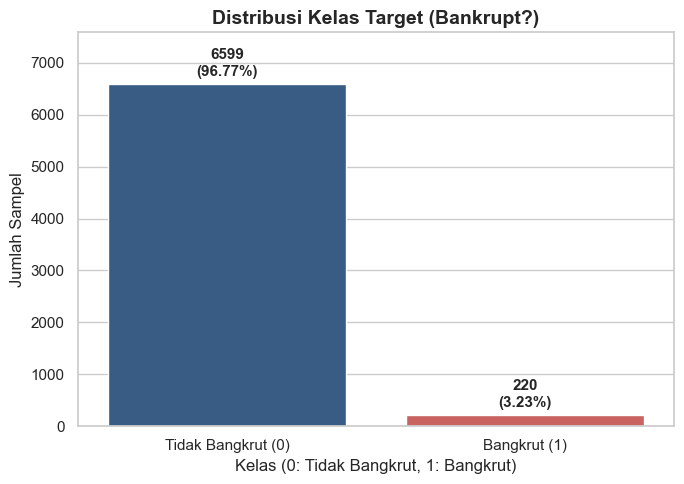

In [3]:
target_counts = df['Bankrupt?'].value_counts()
target_pct = df['Bankrupt?'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, palette=['#2b5c8f', '#d9534f'], legend=False)
plt.title('Distribusi Kelas Target (Bankrupt?)', fontsize=14, fontweight='bold')
plt.xlabel('Kelas (0: Tidak Bangkrut, 1: Bangkrut)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.xticks([0, 1], ['Tidak Bangkrut (0)', 'Bangkrut (1)'])

for i, count in enumerate(target_counts.values):
    pct = target_pct.values[i]
    ax.text(i, count + 100, f"{count}\n({pct:.2f}%)", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(target_counts.values) * 1.15)
plt.tight_layout()
plt.show()

keliatan banget kalau datanya imbalanced, harusnya menyesuaikan weightdengan ngasih penalti, atau resampling

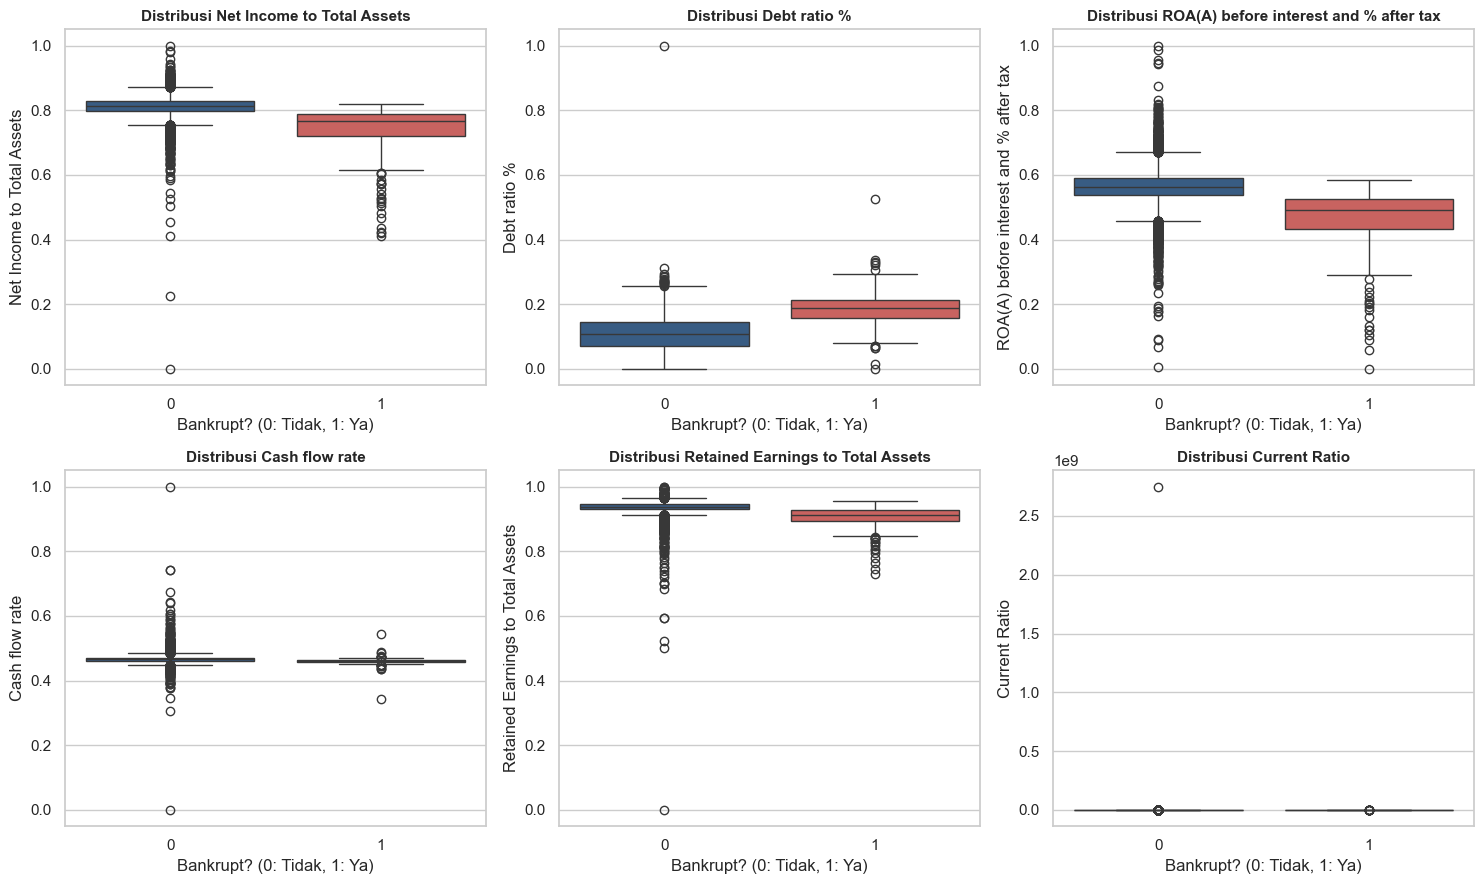

In [4]:
key_features = ['Net Income to Total Assets','Debt ratio %','ROA(A) before interest and % after tax','Cash flow rate','Retained Earnings to Total Assets','Current Ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='Bankrupt?', y=col, data=df, ax=axes[i], hue='Bankrupt?', palette=['#2b5c8f', '#d9534f'], legend=False)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Bankrupt? (0: Tidak, 1: Ya)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Keliatan jelas bedanya, perusahaan yang bangkrut punya net income dan ROA yang jauh lebih rendah, sementara Debt Ratio nya lebih tinggi dibanding perusahaan sehat. Walaupun ada outlier ekstrem kayak di current ratio yang bikin plot nya gepeng, fitur fitur utama ini udah punya pola pemisah yang cukup bagus buat ngebantu model ngebedain mana perusahaan sehat dan mana yang mau bangkrut.

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Jumlah baris duplikat: 0
Fitur bernilai tunggal (konstan/varians nol): ['Net Income Flag']


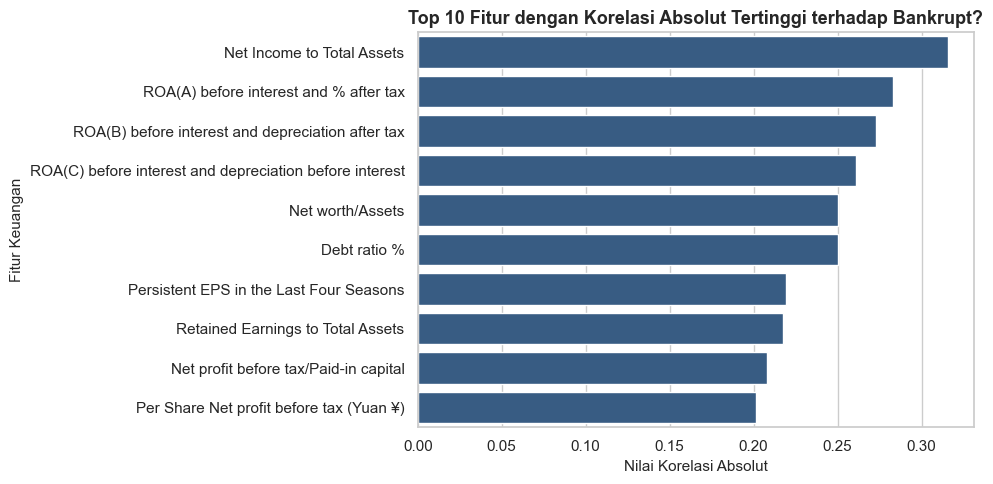

In [5]:
# 1. Cek baris duplikat dalam dataset
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

# 2. Cek apakah ada fitur yang memiliki varians nol (fitur konstan)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Fitur bernilai tunggal (konstan/varians nol): {constant_cols}")

# 3. Analisis korelasi fitur terhadap target 'Bankrupt?'
top_corr = df.corr()['Bankrupt?'].abs().sort_values(ascending=False).iloc[1:11]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, color='#2b5c8f')
plt.title('Top 10 Fitur dengan Korelasi Absolut Tertinggi terhadap Bankrupt?', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Korelasi Absolut', fontsize=11)
plt.ylabel('Fitur Keuangan', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
missing_per_col = df.isnull().sum()
total_missing = missing_per_col.sum()

print(f"Total missing values pada dataset: {total_missing}")

if total_missing == 0:
    print("Dataset sudah bersih dari missing value. Tidak diperlukan imputasi atau pembersihan missing value.")
else:
    pass

Total missing values pada dataset: 0
Dataset sudah bersih dari missing value. Tidak diperlukan imputasi atau pembersihan missing value.


In [7]:
categorical_cols = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
print(f"Kolom kategorikal (non-numerik): {categorical_cols}")
if len(categorical_cols) == 0:
    print("Seluruh fitur dalam dataset bankruptcy.csv sudah bertipe numerik (int64/float64).")
    print("Oleh karena itu, tidak diperlukan proses encoding (One-Hot / Ordinal Encoding).")

if 'Net Income Flag' in df.columns:
    df_clean = df.drop(columns=['Net Income Flag'])
    print("Fitur konstan 'Net Income Flag' telah dihapus.")
else:
    df_clean = df.copy()

Kolom kategorikal (non-numerik): []
Seluruh fitur dalam dataset bankruptcy.csv sudah bertipe numerik (int64/float64).
Oleh karena itu, tidak diperlukan proses encoding (One-Hot / Ordinal Encoding).
Fitur konstan 'Net Income Flag' telah dihapus.


In [8]:
X = df_clean.drop(columns=['Bankrupt?'])
y = df_clean['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Bentuk X_train : {X_train.shape}")
print(f"Bentuk X_test  : {X_test.shape}")
print("\n" + "="*50 + "\n")

print(y_train.value_counts(normalize=True) * 100)

print(y_test.value_counts(normalize=True) * 100)

Bentuk X_train : (5455, 94)
Bentuk X_test  : (1364, 94)


Bankrupt?
0    96.773602
1     3.226398
Name: proportion, dtype: float64
Bankrupt?
0    96.774194
1     3.225806
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [9]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

print("Model Decision Tree (Gini) berhasil dilatih.")

Model Decision Tree (Gini) berhasil dilatih.


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)

print(f"Jumlah sampel terprediksi: {len(y_pred_gini)}")

Jumlah sampel terprediksi: 1364


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

print("Model Decision Tree (Entropy) berhasil dilatih.")

Model Decision Tree (Entropy) berhasil dilatih.


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)

print(f"Jumlah sampel terprediksi: {len(y_pred_entropy)}")

Jumlah sampel terprediksi: 1364


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
max_depth_values = [1, 2, 3, 5, 10, None]
models_depth = {}

for depth in max_depth_values:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    models_depth[depth] = model

print("Pelatihan model untuk berbagai variasi max_depth selesai.")

Pelatihan model untuk berbagai variasi max_depth selesai.


In [14]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_accuracies = []
test_accuracies = []

for depth, model in models_depth.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

depth_labels = [str(d) if d is not None else 'None' for d in max_depth_values]
df_acc_results = pd.DataFrame({
    'max_depth': depth_labels,
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies
})

print(df_acc_results)

  max_depth  Train Accuracy  Test Accuracy
0         1        0.967736       0.967742
1         2        0.969936       0.969941
2         3        0.972319       0.971408
3         5        0.977452       0.969208
4        10        0.994684       0.961144
5      None        1.000000       0.961144


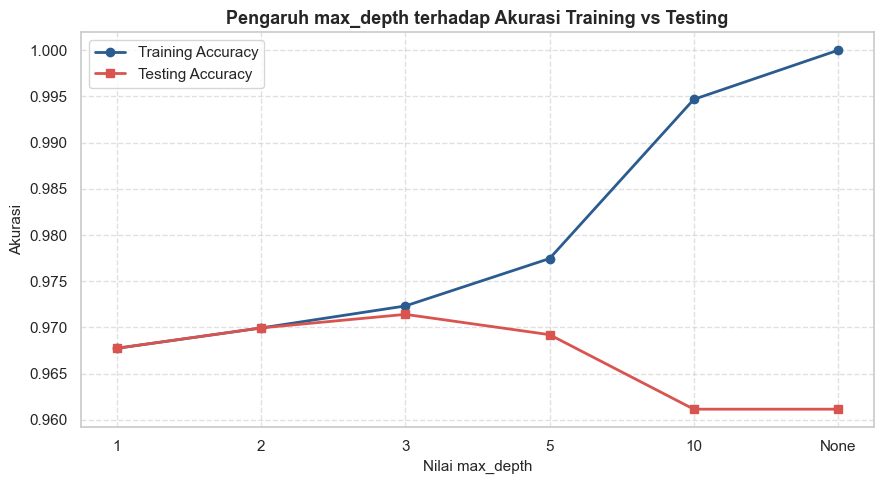

In [15]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
plt.figure(figsize=(9, 5))
plt.plot(depth_labels, train_accuracies, marker='o', linewidth=2, label='Training Accuracy', color='#2b5c8f')
plt.plot(depth_labels, test_accuracies, marker='s', linewidth=2, label='Testing Accuracy', color='#d9534f')

plt.title('Pengaruh max_depth terhadap Akurasi Training vs Testing', fontsize=13, fontweight='bold')
plt.xlabel('Nilai max_depth', fontsize=11)
plt.ylabel('Akurasi', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

di max_depth = 3 akurasi testing-nya paling optimal. Pas kedalamannya ditambah melebihi 3, akurasi training-nya malah meroket makin tinggi sampai 100%, sementara akurasi testingnya malah drop dan stagnan ini tanda jelas banget kalau modelnya mulai overfitting

# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

# Gini
acc_gini = accuracy_score(y_test, y_pred_gini)
prec_gini = precision_score(y_test, y_pred_gini, zero_division=0)
rec_gini = recall_score(y_test, y_pred_gini, zero_division=0)
f1_gini = f1_score(y_test, y_pred_gini, zero_division=0)

# Entropy
acc_entropy = accuracy_score(y_test, y_pred_entropy)
prec_entropy = precision_score(y_test, y_pred_entropy, zero_division=0)
rec_entropy = recall_score(y_test, y_pred_entropy, zero_division=0)
f1_entropy = f1_score(y_test, y_pred_entropy, zero_division=0)

df_evaluation = pd.DataFrame({'Model': ['Decision Tree (Gini)', 'Decision Tree (Entropy)'],'Accuracy': [acc_gini, acc_entropy],'Precision': [prec_gini, prec_entropy],'Recall': [rec_gini, rec_entropy],'F1-Score': [f1_gini, f1_entropy]})

print("Tabel Perbandingan Metrik Evaluasi Model:")
print(df_evaluation.to_string(index=False))

Tabel Perbandingan Metrik Evaluasi Model:
                  Model  Accuracy  Precision   Recall  F1-Score
   Decision Tree (Gini)  0.961144   0.395349 0.386364  0.390805
Decision Tree (Entropy)  0.958944   0.357143 0.340909  0.348837


beda kriteria Gini sama Entropy tipis, tapi Gini sedikit lebih unggul di semua metrik. Walaupun akurasinya keliatan tinggi di angka 96 persen, nilai Precision, Recall, dan F1 Score dapetnya rendah cuma kisaran 34 persen sampai 39 persen. Ini bukti nyata jebakan akurasi akibat imbalanced data, bikin model kesulitan ngenalin perusahaan yang beneran bangkrut

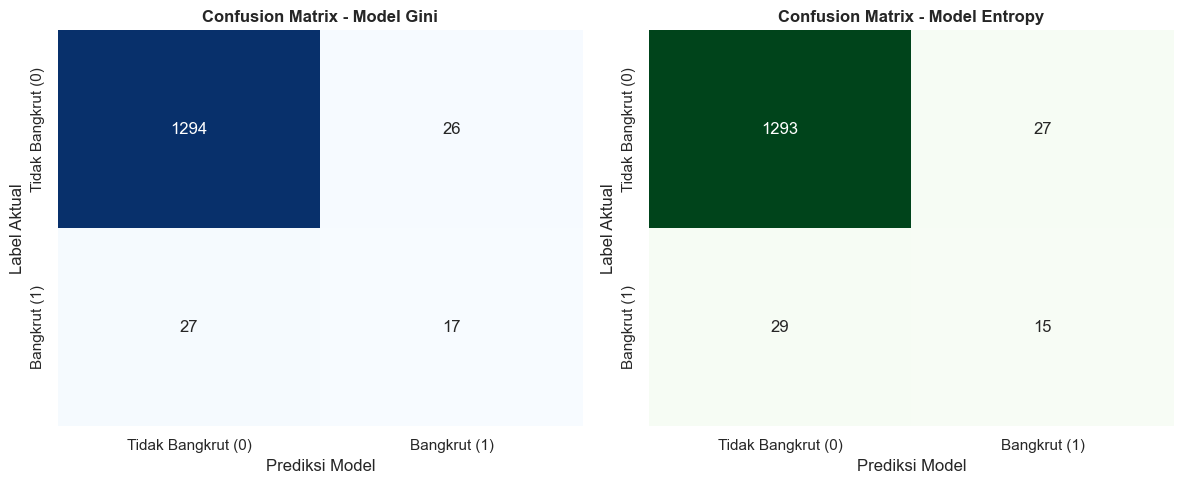

In [17]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap Confusion Matrix Model Gini
sns.heatmap(
    cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
    xticklabels=['Tidak Bangkrut (0)', 'Bangkrut (1)'],
    yticklabels=['Tidak Bangkrut (0)', 'Bangkrut (1)']
)
axes[0].set_title('Confusion Matrix - Model Gini', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Label Aktual')

# Heatmap Confusion Matrix Model Entropy
sns.heatmap(
    cm_entropy, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False,
    xticklabels=['Tidak Bangkrut (0)', 'Bangkrut (1)'],
    yticklabels=['Tidak Bangkrut (0)', 'Bangkrut (1)']
)
axes[1].set_title('Confusion Matrix - Model Entropy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Label Aktual')

plt.tight_layout()
plt.show()

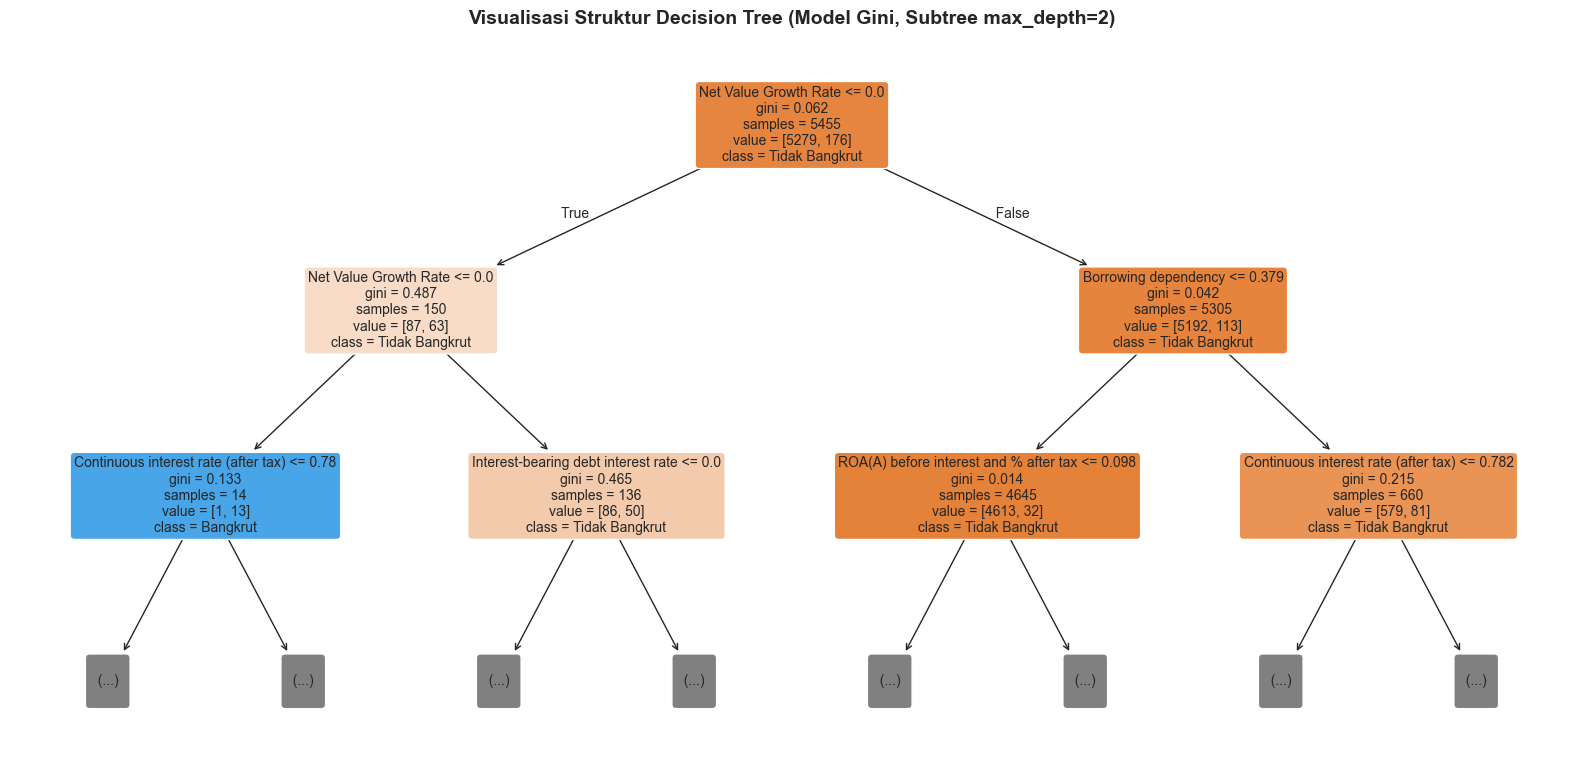

In [18]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

plt.figure(figsize=(16, 8))
plot_tree(
    dt_gini,
    max_depth=2,
    feature_names=X.columns,
    class_names=['Tidak Bangkrut', 'Bangkrut'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Visualisasi Struktur Decision Tree (Model Gini, Subtree max_depth=2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

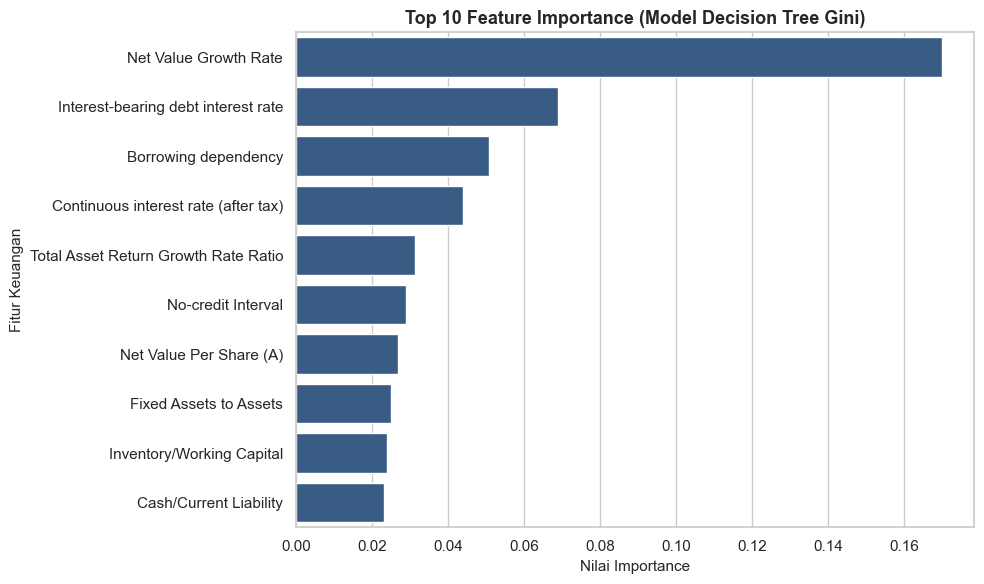

Top 10 Fitur Paling Berpengaruh:
Net Value Growth Rate                   0.169812
Interest-bearing debt interest rate     0.068871
Borrowing dependency                    0.050665
Continuous interest rate (after tax)    0.043817
Total Asset Return Growth Rate Ratio    0.031184
No-credit Interval                      0.028890
Net Value Per Share (A)                 0.026742
Fixed Assets to Assets                  0.024890
Inventory/Working Capital               0.023758
Cash/Current Liability                  0.023187
dtype: float64


In [19]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

importances = dt_gini.feature_importances_
top_features = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, color='#2b5c8f')
plt.title('Top 10 Feature Importance (Model Decision Tree Gini)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Importance', fontsize=11)
plt.ylabel('Fitur Keuangan', fontsize=11)
plt.tight_layout()
plt.show()

print("Top 10 Fitur Paling Berpengaruh:")
print(top_features)

# 5. Analisis


Perbandingan Kriteria Split: Gini vs Entropy
- Hasil Eksperimen: Model dengan kriteria Gini Impurity menghasilkan akurasi sebesar 96.11% (F1-Score: 39.08%), sedangkan model dengan kriteria Entropy menghasilkan akurasi sebesar 95.89% (F1-Score: 34.88%).
- Signifikansi Perbedaan: Hasil antara Gini dan Entropy tidak berbeda secara signifikan, dengan selisih akurasi hanya sekitar 0.22%.
- Penyebab: Secara teoritis, baik Gini Impurity maupun Entropy mengukur tingkat ketidakmurnian (impurity) node secara monotonik. Pada rentang probabilitas 0 sampai 1, fungsi Gini dan Entropy memiliki bentuk kurva yang sangat mirip. Pada dataset numerik berdimensi tinggi seperti bankruptcy, kedua fungsi ini menghasilkan kandidat pemisahan (split threshold) yang hampir identik untuk sebagian besar fitur.

Temuan Eksperimen Regularisasi (max_depth) dan Overfitting
- Titik Mulai Overfitting: Gejala overfitting mulai terlihat jelas saat nilai max_depth lebih dari 3, khususnya mulai dari max_depth sama dengan 5.
- Ciri-Ciri pada Grafik:
  - Kondisi Optimal (max_depth sama dengan 3): Akurasi training mencapai 97.23% dan akurasi testing mencapai titik tertinggi yaitu 97.14%. Pada titik ini, jarak antara akurasi training dan testing sangat kecil (sekitar 0.09%).
  - Gejala Overfitting (max_depth lebih dari atau sama dengan 5): Saat kedalaman pohon terus ditambah ke 5, 10, hingga None (tanpa batas), akurasi pada training set terus naik hingga mencapai 100.00%. Sebaliknya, akurasi testing justru mengalami penurunan dan stagnan di angka 96.11%.
  - Jarak yang semakin lebar antara kurva akurasi training dan testing mengindikasikan bahwa pohon yang terlalu dalam menyerap noise dan outlier spesifik dari data training sehingga kemampuan generalisasinya terhadap data baru menurun.

Analisis Feature Importance
- Fitur Paling Berpengaruh: Fitur yang memiliki kontribusi paling dominan terhadap keputusan model adalah Net Value Growth Rate dengan nilai importance terbesar yaitu sekitar 16.98%.
- Fitur Pendukung Utama: Fitur berpengaruh berikutnya secara berurutan adalah:
  1. Interest-bearing debt interest rate (sekitar 6.89%)
  2. Borrowing dependency (sekitar 5.07%)
  3. Continuous interest rate (after tax) (sekitar 4.38%)
  4. Total Asset Return Growth Rate Ratio (sekitar 3.12%)
- Interpretasi Bisnis: Hal ini menunjukkan bahwa indikator pertumbuhan nilai bersih perusahaan (equity growth) serta tingkat beban dan ketergantungan terhadap utang (debt burden) merupakan sinyal keuangan paling kritis dalam memprediksi risiko kebangkrutan suatu perusahaan.



# 6. Kesimpulan dan Saran

Kesimpulan
1. Kriteria split Gini Impurity dan Entropy menghasilkan performa generalisasi yang relatif setara pada dataset kebangkrutan perusahaan ini, dengan Gini sedikit lebih unggul pada metrik F1-Score dan Recall.
2. Pengaturan hyperparameter max_depth terbukti efektif sebagai metode regularisasi (pre-pruning) untuk mengatasi overfitting. Pohon keputusan dengan max_depth sama dengan 3 memberikan keseimbangan terbaik (bias-variance tradeoff) dengan akurasi testing sebesar 97.14%.
3. Tantangan utama pada dataset ini terletak pada tingginya tingkat ketidakseimbangan kelas (imbalanced data, di mana perusahaan bangkrut hanya sekitar 3.23%), sehingga model default cenderung berfokus memaksimalkan prediksi pada kelas mayoritas (perusahaan sehat).

Saran
1. Handling Class Imbalance: Menerapkan teknik pemulihan keseimbangan data seperti SMOTE (Synthetic Minority Over-sampling Technique) atau mengatur parameter class_weight sama dengan balanced pada DecisionTreeClassifier agar model lebih sensitif dalam mendeteksi perusahaan yang terancam bangkrut (meningkatkan Recall).
2. Cost-Complexity Pruning (ccp_alpha): Melakukan post-pruning menggunakan metode Cost-Complexity Pruning dengan mencari nilai ccp_alpha optimal untuk pemangkasan cabang pohon secara lebih sistematis dibandingkan pembatasan kedalaman manual.
3. Eksplorasi Hyperparameter Lain: Mengombinasikan max_depth dengan hyperparameter lain seperti min_samples_split, min_samples_leaf, dan max_features melalui pencarian otomatis seperti GridSearchCV.
4. Penggunaan Model Ensemble: Membandingkan hasil Decision Tree tunggal dengan algoritma Tree-based Ensemble seperti Random Forest atau XGBoost untuk meningkatkan stabilitas dan akurasi prediksi.